In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import convolve, Gaussian2DKernel
from scipy.signal import convolve2d
from matplotlib.colors import LogNorm
from astropy.visualization import ZScaleInterval



In [2]:
# generate a detector image with a Gaussian PSF in the middle

detector_array = np.zeros((2048, 2048))

# Define the PSF parameters
fwhm_pix = 20.0  # Full Width at Half Maximum in pixels
sigma_pix = fwhm_pix / (2.0 * np.sqrt(2.0 * np.log(2.0)))  # Convert FWHM to sigma
#mu = 20

detector_array_xx, detector_array_yy = np.meshgrid(np.arange(2048), np.arange(2048))

# Create a 2D Gaussian PSF
center_x, center_y = 1024, 1024  # Center of the array
dst = np.sqrt((detector_array_xx - center_x) ** 2 + (detector_array_yy - center_y) ** 2)

# Normalization for a 2D Gaussian
normal = 1 / (2 * np.pi * sigma_pix**2)

# Calculate Gaussian filter centered in the array
exp_part = np.exp(-((dst) ** 2) / (2.0 * sigma_pix**2))
detector_array = 1 * exp_part/np.max(exp_part) + 0.01 * np.random.randn(2048, 2048)

#detector_array += psf_xx
#detector_array += psf_yy

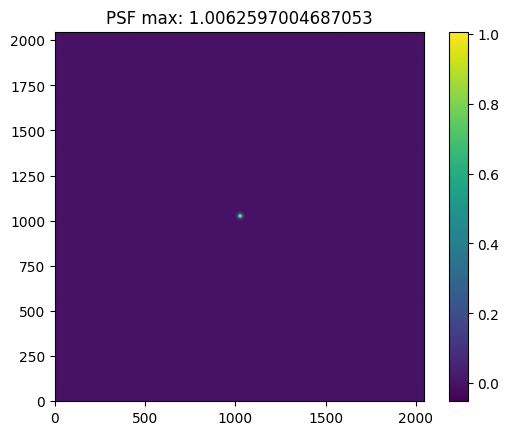

In [3]:
plt.imshow(detector_array, origin='lower')
plt.title('PSF max: ' + str(np.max(detector_array)))
plt.colorbar()
plt.show()

In [4]:
def random_contiguous_stray_light(
    shape,
    n_shapes=(3, 8),
    seed=None,
    pixels_per_shape=(80, 600),
    growth_p=0.65,
    intensity_range=(5.0, 60.0),
    smooth_edges=False,
):
    """
    Generate random contiguous stray-light shapes on a 2D detector frame.

    Parameters
    ----------
    shape : tuple[int, int]
        (ny, nx) detector shape.
    n_shapes : int or tuple[int, int]
        Number of shapes, or (min, max) inclusive.
    seed : int or None
        RNG seed.
    pixels_per_shape : tuple[int, int]
        Target number of pixels per shape (min, max).
    growth_p : float
        Probability to grow from existing frontier pixel vs random frontier pixel.
    intensity_range : tuple[float, float]
        Per-shape constant intensity (ADU) sampled uniformly in this range.
    smooth_edges : bool
        If True, apply a tiny averaging blur to soften jagged boundaries.

    Returns
    -------
    stray : ndarray
        2D array with random contiguous shapes.
    label_map : ndarray[int]
        Integer map of shape IDs (0 background, 1..N shapes).
    """
    rng = np.random.default_rng(seed)
    ny, nx = shape
    stray = np.zeros((ny, nx), dtype=float)
    label_map = np.zeros((ny, nx), dtype=int)

    if isinstance(n_shapes, int):
        n_obj = n_shapes
    else:
        n_obj = int(rng.integers(n_shapes[0], n_shapes[1] + 1))

    # 8-neighborhood
    nbrs = [(-1, -1), (-1, 0), (-1, 1),
            ( 0, -1),          ( 0, 1),
            ( 1, -1), ( 1, 0), ( 1, 1)]

    occupied = np.zeros((ny, nx), dtype=bool)

    for obj_id in range(1, n_obj + 1):
        target = int(rng.integers(pixels_per_shape[0], pixels_per_shape[1] + 1))
        intensity = float(rng.uniform(*intensity_range))

        # pick seed in free space
        free = np.argwhere(~occupied)
        if free.size == 0:
            break
        sy, sx = free[rng.integers(len(free))]

        pixels = {(int(sy), int(sx))}
        frontier = {(int(sy), int(sx))}

        while len(pixels) < target and frontier:
            # choose growth source
            if rng.random() < growth_p:
                cy, cx = list(frontier)[rng.integers(len(frontier))]
            else:
                cy, cx = list(frontier)[rng.integers(len(frontier))]

            # collect candidate neighbors
            cands = []
            for dy, dx in nbrs:
                yy, xx = cy + dy, cx + dx
                if 0 <= yy < ny and 0 <= xx < nx and not occupied[yy, xx] and (yy, xx) not in pixels:
                    cands.append((yy, xx))

            if not cands:
                frontier.discard((cy, cx))
                continue

            yy, xx = cands[rng.integers(len(cands))]
            pixels.add((yy, xx))
            frontier.add((yy, xx))

            # if source is boxed in now, drop it
            has_free_nbr = any(
                0 <= cy + dy < ny and 0 <= cx + dx < nx and
                (not occupied[cy + dy, cx + dx]) and ((cy + dy, cx + dx) not in pixels)
                for dy, dx in nbrs
            )
            if not has_free_nbr:
                frontier.discard((cy, cx))

        # paint shape
        for yy, xx in pixels:
            stray[yy, xx] += intensity
            label_map[yy, xx] = obj_id
            occupied[yy, xx] = True

    if smooth_edges:
        # small 3x3 mean filter without scipy dependency
        pad = np.pad(stray, 1, mode="edge")
        out = np.zeros_like(stray)
        for j in range(ny):
            for i in range(nx):
                out[j, i] = pad[j:j+3, i:i+3].mean()
        stray = out

    return stray, label_map

In [ ]:
# crescent shape

def add_crescent(detector_array, center, width, height, angle, amplitude=0.5):
    """
    Add a crescent shape to the detector array.

    The crescent is the set difference of two disks of equal radius
    (moon-phase geometry).

    Parameters
    ----------
    detector_array : ndarray
        2D image to which the crescent is added (not modified in place).
    center : tuple[float, float]
        (x, y) pixel coordinates of the crescent center.
    width : float
        Outer radius of the crescent in pixels.
    height : float
        Approximate thickness of the bright crescent arc in pixels.
    angle : float
        Orientation of the crescent opening, in radians
        (0 opens toward +x).
    amplitude : float
        Constant intensity added inside the crescent mask.

    Returns
    -------
    ndarray
        Copy of ``detector_array`` with the crescent added.
    """
    out = np.array(detector_array, dtype=float, copy=True)
    ny, nx = out.shape
    cx, cy = float(center[0]), float(center[1])

    yy, xx = np.indices((ny, nx))
    r_outer = float(width)
    thickness = max(1.0, float(height))

    # Cutting disk: same radius as outer, shifted so the leftover arc
    # has characteristic thickness ~height.
    offset = max(0.0, r_outer - thickness)
    cut_cx = cx + offset * np.cos(angle)
    cut_cy = cy + offset * np.sin(angle)

    in_outer = (xx - cx) ** 2 + (yy - cy) ** 2 <= r_outer ** 2
    in_cut = (xx - cut_cx) ** 2 + (yy - cut_cy) ** 2 <= r_outer ** 2
    mask = in_outer & ~in_cut

    out[mask] += amplitude
    return out
    
    Parameters:
        detector_array: numpy array
            The detector array to add the crescent to.
        center: tuple
            The center of the crescent.
        width: int
            The width of the crescent.

            


    

In [5]:
# generate some stray light shapes

# same shape as detector/readout
stray_rand, labels = random_contiguous_stray_light(
    shape=detector_array.shape,
    n_shapes=(4, 10),
    seed=123,
    pixels_per_shape=(100, 1200),
    intensity_range=(0.01, 0.3),
)

# dots
net_readout_dots = detector_array + stray_rand

# add a crescent
net_readout_crescent = add_crescent(detector_array, (1024, 1024), 100, 10, 0.1)


NameError: name 'add_crescent' is not defined

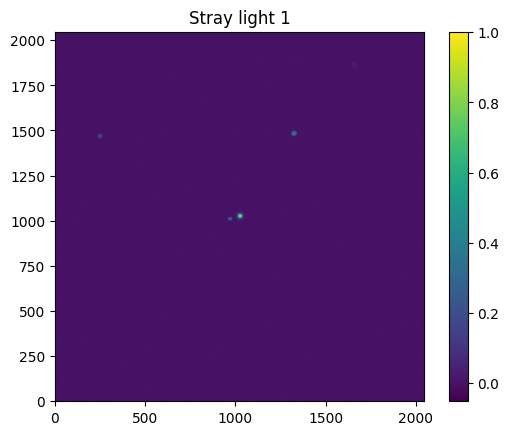

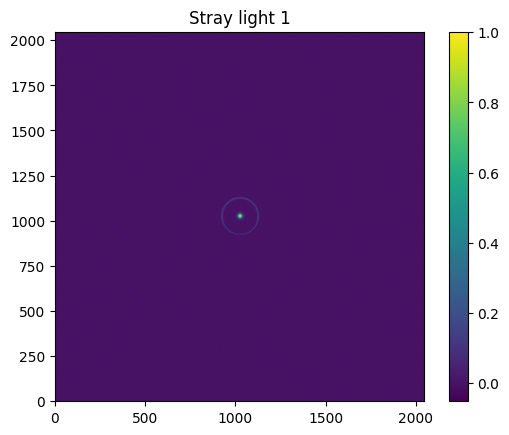

In [56]:
plt.clf()
plt.imshow(net_readout_dots, origin='lower')
plt.title('Stray light 1')
plt.colorbar()
plt.show()

plt.clf()
plt.imshow(net_readout_crescent, origin='lower')
plt.title('Stray light 1')
plt.colorbar()
plt.show()





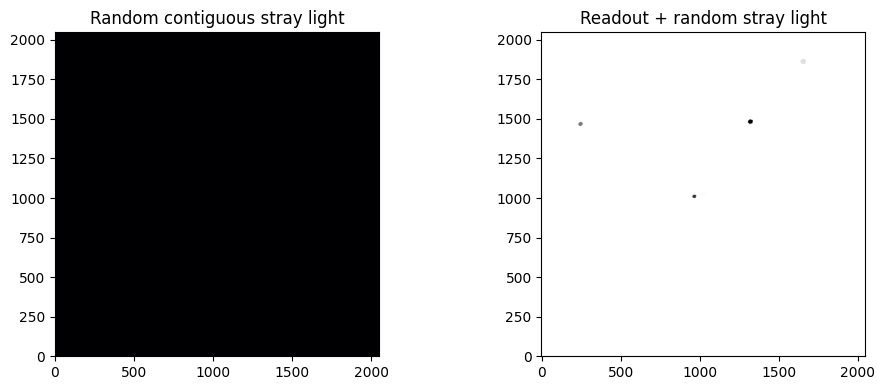

In [38]:
z = ZScaleInterval()
v1, v2 = z.get_limits(stray_rand)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(stray_rand, origin="lower", cmap="inferno", vmin=v1, vmax=v2)
ax[0].set_title("Random contiguous stray light")
ax[1].imshow(net_readout_rand, origin="lower", cmap="gray_r")
ax[1].set_title("Readout + random stray light")
plt.tight_layout()
plt.show()